In [1]:
# Section 1 — Imports + Load Stage 1 Checkpoint + Load Kaggle Train

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Project paths
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'

X_TRAIN_PICKLE = DATA_DIR / 'x_train.pkl'
STAGE1_CHECKPOINT = CHECKPOINTS_DIR / 'stage1_reader_imagination.pt'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Architecture dimensions (must match Notebook 02 — these are the contract)
INPUT_DIM = 13
LATENT_DIM = 32
CONCEPT_DIM = 6

FEATURE_NAMES = [
    'lap_time_norm', 'lap_time_delta', 'cumulative_degradation',
    'tyre_life_norm', 'compound_soft', 'compound_medium', 'compound_hard',
    'compound_inter', 'compound_wet', 'position_norm', 'position_change_norm',
    'race_progress', 'stint_norm',
]
CONCEPT_NAMES = [
    'degradation_severity', 'pace_decay_rate', 'strategic_window',
    'track_position_risk', 'undercut_pressure', 'endgame_proximity',
]


# ── Re-define model classes (must match Notebook 02 exactly)
class Reader(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, latent_dim)
        self.ln1 = nn.LayerNorm(latent_dim)
        self.fc2 = nn.Linear(latent_dim, latent_dim)
        self.ln2 = nn.LayerNorm(latent_dim)
        self.fc3 = nn.Linear(latent_dim, latent_dim)
    
    def forward(self, x):
        h = F.relu(self.ln1(self.fc1(x)))
        h = F.relu(self.ln2(self.fc2(h)))
        z = self.fc3(h)
        return z


class ConceptBlock(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, concept_dim=CONCEPT_DIM, hidden_dim=16):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, concept_dim)
    
    def forward(self, z):
        h = F.relu(self.ln1(self.fc1(z)))
        c = torch.sigmoid(self.fc2(h))
        return c


# ── Load Stage 1 checkpoint and instantiate Reader with trained weights
print("=" * 70)
print("LOADING STAGE 1 CHECKPOINT")
print("=" * 70)

ckpt = torch.load(STAGE1_CHECKPOINT, weights_only=False)
reader = Reader().to(DEVICE)
reader.load_state_dict(ckpt['reader_state_dict'])

# Freeze the Reader — its weights will not change in Stage 2
for p in reader.parameters():
    p.requires_grad = False
reader.eval()

print(f"  Stage 1 best epoch:     {ckpt['best_epoch']}")
print(f"  Stage 1 best val_recon: {ckpt['best_val_recon']:.5f}")
print(f"  Reader loaded and frozen ({sum(p.numel() for p in reader.parameters()):,} params, none trainable)")


# ── Load Kaggle train data
print("\n" + "=" * 70)
print("LOADING KAGGLE TRAIN DATA")
print("=" * 70)

x_train_df = pd.read_pickle(X_TRAIN_PICKLE)
print(f"  Shape: {x_train_df.shape}")
print(f"  Columns: id, 13 x_*, 6 c_*, PitNextLap")

# Verify expected columns
x_cols = [f'x_{n}' for n in FEATURE_NAMES]
c_cols = [f'c_{n}' for n in CONCEPT_NAMES]
assert all(c in x_train_df.columns for c in x_cols), "Missing x_ columns"
assert all(c in x_train_df.columns for c in c_cols), "Missing c_ columns"
print(f"  All expected columns present ✓")

LOADING STAGE 1 CHECKPOINT
  Stage 1 best epoch:     7
  Stage 1 best val_recon: 0.20416
  Reader loaded and frozen (2,688 params, none trainable)

LOADING KAGGLE TRAIN DATA
  Shape: (439140, 21)
  Columns: id, 13 x_*, 6 c_*, PitNextLap
  All expected columns present ✓


In [2]:
# Section 2 — Verify Frozen Reader on Kaggle Train

print("=" * 70)
print("VERIFYING FROZEN READER ON KAGGLE TRAIN")
print("=" * 70)

# Build the x tensor from the loaded dataframe
x_cols = [f'x_{n}' for n in FEATURE_NAMES]
c_cols = [f'c_{n}' for n in CONCEPT_NAMES]

x_train_arr = x_train_df[x_cols].values.astype(np.float32)
c_train_arr = x_train_df[c_cols].values.astype(np.float32)
pit_train_arr = x_train_df['PitNextLap'].values.astype(np.int64)

print(f"\nx_train shape:    {x_train_arr.shape}")
print(f"c_train shape:    {c_train_arr.shape}")
print(f"pit_train shape:  {pit_train_arr.shape}")
print(f"\nAny NaN in x?     {np.isnan(x_train_arr).any()}")
print(f"Any NaN in c_gt?  {np.isnan(c_train_arr).any()}")


# ── Run Reader on a chunk of Kaggle train and check z distribution
print("\n" + "=" * 70)
print("READER OUTPUT SANITY (on first 10,000 Kaggle train rows)")
print("=" * 70)

with torch.no_grad():
    sample_x = torch.from_numpy(x_train_arr[:10000]).to(DEVICE)
    sample_z = reader(sample_x).cpu().numpy()

print(f"\nz shape:                 {sample_z.shape}")
print(f"z value range:           [{sample_z.min():.4f}, {sample_z.max():.4f}]")
print(f"z mean (per dim):        [{sample_z.mean(axis=0).min():+.4f}, {sample_z.mean(axis=0).max():+.4f}]")
print(f"z std (per dim):         [{sample_z.std(axis=0).min():.4f}, {sample_z.std(axis=0).max():.4f}]")
print(f"Any NaN in z?            {np.isnan(sample_z).any()}")
print(f"Any Inf in z?            {np.isinf(sample_z).any()}")

# Check: does z vary across samples? (Catastrophic collapse would show all z's identical)
z_sample_variance = sample_z.var(axis=0).mean()
print(f"\nMean per-dim variance:   {z_sample_variance:.4f}")
print(f"(Should be > 0 — if near zero, all z's are identical = bad)")


# ── Concept GT distribution check (from x_train_df, computed in Notebook 01)
print("\n" + "=" * 70)
print("CONCEPT GROUND TRUTH DISTRIBUTION (Kaggle train, all rows)")
print("=" * 70)

for j, name in enumerate(CONCEPT_NAMES):
    vals = c_train_arr[:, j]
    print(f"  {name:<22s}  mean={vals.mean():.3f}  std={vals.std():.3f}  "
          f"frac>0={np.mean(vals > 0):.1%}  frac>0.5={np.mean(vals > 0.5):.1%}")


# ── Per-class concept distribution (the most useful diagnostic)
print("\n" + "=" * 70)
print("CONCEPT MEANS BY CLASS (PitNextLap=0 vs PitNextLap=1)")
print("=" * 70)

print(f"\n{'concept':<24s} | {'PitNextLap=0':>14s} | {'PitNextLap=1':>14s} | {'difference':>11s}")
print("-" * 75)
for j, name in enumerate(CONCEPT_NAMES):
    vals = c_train_arr[:, j]
    mean_no_pit = vals[pit_train_arr == 0].mean()
    mean_pit = vals[pit_train_arr == 1].mean()
    diff = mean_pit - mean_no_pit
    arrow = "↑" if diff > 0.01 else ("↓" if diff < -0.01 else "—")
    print(f"  {name:<22s} | {mean_no_pit:>14.4f} | {mean_pit:>14.4f} | {diff:>+10.4f} {arrow}")

VERIFYING FROZEN READER ON KAGGLE TRAIN

x_train shape:    (439140, 13)
c_train shape:    (439140, 6)
pit_train shape:  (439140,)

Any NaN in x?     False
Any NaN in c_gt?  False

READER OUTPUT SANITY (on first 10,000 Kaggle train rows)

z shape:                 (10000, 32)
z value range:           [-2.1952, 1.9997]
z mean (per dim):        [-1.4013, +1.2711]
z std (per dim):         [0.1351, 0.3906]
Any NaN in z?            False
Any Inf in z?            False

Mean per-dim variance:   0.0595
(Should be > 0 — if near zero, all z's are identical = bad)

CONCEPT GROUND TRUTH DISTRIBUTION (Kaggle train, all rows)
  degradation_severity    mean=0.208  std=0.289  frac>0=49.8%  frac>0.5=17.2%
  pace_decay_rate         mean=0.145  std=0.245  frac>0=38.2%  frac>0.5=4.0%
  strategic_window        mean=0.139  std=0.270  frac>0=28.3%  frac>0.5=13.8%
  track_position_risk     mean=0.368  std=0.368  frac>0=55.3%  frac>0.5=23.2%
  undercut_pressure       mean=0.178  std=0.364  frac>0=20.5%  frac>0.

In [3]:
# Section 3 — Stage 2 Dataset, Train/Val Split, and Training Loop

import time

print("=" * 70)
print("STAGE 2 DATASET BUILD")
print("=" * 70)

# Compute z for all Kaggle train rows (Reader is frozen, so we can precompute)
print("\nPrecomputing z for all Kaggle train rows...")
t_start = time.time()
with torch.no_grad():
    x_tensor = torch.from_numpy(x_train_arr).to(DEVICE)
    # Process in chunks for memory safety on CPU
    chunk_size = 50000
    z_chunks = []
    for i in range(0, len(x_tensor), chunk_size):
        z_chunk = reader(x_tensor[i:i+chunk_size]).cpu().numpy()
        z_chunks.append(z_chunk)
    z_train_arr = np.concatenate(z_chunks, axis=0)
print(f"  z shape: {z_train_arr.shape}  (computed in {time.time()-t_start:.1f}s)")


# ── Train/val split by (Race, Year)
print("\n" + "=" * 70)
print("TRAIN/VAL SPLIT BY (Race, Year)")
print("=" * 70)

# We need Race/Year per row. They're not in x_train.pkl directly, so we
# read them from the original CSV (already loaded? no — need to read again)
KAGGLE_TRAIN_CSV = DATA_DIR / 'train.csv'
kaggle_train_raw = pd.read_csv(KAGGLE_TRAIN_CSV)
kaggle_train_raw.columns = kaggle_train_raw.columns.str.strip()

# Verify alignment via id
assert (kaggle_train_raw['id'].values == x_train_df['id'].values).all(), "id mismatch — rows out of order"
print("  Kaggle train CSV loaded, id alignment confirmed ✓")

race_year = kaggle_train_raw['Race'].astype(str) + '_' + kaggle_train_raw['Year'].astype(str)
unique_combos = race_year.unique()
print(f"  Unique (Race, Year) combos: {len(unique_combos)}")

rng = np.random.RandomState(SEED)
shuffled = rng.permutation(len(unique_combos))
n_val = int(0.2 * len(unique_combos))
val_combos = set(unique_combos[shuffled[:n_val]])
train_combos = set(unique_combos[shuffled[n_val:]])

train_mask = race_year.isin(train_combos).values
val_mask = race_year.isin(val_combos).values

print(f"  Train: {train_mask.sum():,} rows ({train_mask.mean()*100:.1f}%)")
print(f"  Val:   {val_mask.sum():,} rows ({val_mask.mean()*100:.1f}%)")


# ── Build PyTorch tensors
z_train_t = torch.from_numpy(z_train_arr[train_mask])
c_train_t = torch.from_numpy(c_train_arr[train_mask])
z_val_t = torch.from_numpy(z_train_arr[val_mask])
c_val_t = torch.from_numpy(c_train_arr[val_mask])

print(f"\nTensor shapes:")
print(f"  z_train: {tuple(z_train_t.shape)}  c_train: {tuple(c_train_t.shape)}")
print(f"  z_val:   {tuple(z_val_t.shape)}  c_val:   {tuple(c_val_t.shape)}")

BATCH_SIZE = 512
train_loader = DataLoader(TensorDataset(z_train_t, c_train_t), batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(TensorDataset(z_val_t, c_val_t), batch_size=BATCH_SIZE, shuffle=False)
print(f"\nDataLoaders: train={len(train_loader)} batches, val={len(val_loader)} batches")


# ── Stage 2 training
print("\n" + "=" * 70)
print("STAGE 2 TRAINING (Concept Block only)")
print("=" * 70)

torch.manual_seed(SEED)
concept_block = ConceptBlock().to(DEVICE)
optimizer = torch.optim.AdamW(concept_block.parameters(), lr=1e-3, weight_decay=0.0)

EPOCHS = 15
PATIENCE = 3
best_val_loss = float('inf')
best_epoch = 0
epochs_since_improvement = 0
best_state = None

history = {'epoch': [], 'train_loss': [], 'val_loss': []}

print(f"\n{'epoch':>5s} | {'train_mse':>10s} | {'val_mse':>10s} | {'time(s)':>7s} | note")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    
    # Train
    concept_block.train()
    train_loss = 0.0
    n = 0
    for zb, cb in train_loader:
        zb = zb.to(DEVICE); cb = cb.to(DEVICE)
        optimizer.zero_grad()
        c_pred = concept_block(zb)
        loss = F.mse_loss(c_pred, cb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * zb.size(0)
        n += zb.size(0)
    train_loss /= n
    
    # Val
    concept_block.eval()
    val_loss = 0.0
    n = 0
    with torch.no_grad():
        for zb, cb in val_loader:
            zb = zb.to(DEVICE); cb = cb.to(DEVICE)
            c_pred = concept_block(zb)
            val_loss += F.mse_loss(c_pred, cb).item() * zb.size(0)
            n += zb.size(0)
    val_loss /= n
    
    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    note = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_since_improvement = 0
        best_state = {k: v.cpu().clone() for k, v in concept_block.state_dict().items()}
        note = "↓ new best"
    else:
        epochs_since_improvement += 1
        if epochs_since_improvement >= PATIENCE:
            note = f"early stop (no improvement for {PATIENCE} epochs)"
    
    elapsed = time.time() - t0
    print(f"{epoch:>5d} | {train_loss:>10.5f} | {val_loss:>10.5f} | {elapsed:>7.1f} | {note}")
    
    if epochs_since_improvement >= PATIENCE:
        break


# Restore best
concept_block.load_state_dict(best_state)
print(f"\nBest val MSE = {best_val_loss:.5f} at epoch {best_epoch}")

# Save checkpoint
stage2_path = CHECKPOINTS_DIR / 'stage2_concept_block.pt'
torch.save({
    'concept_block_state_dict': concept_block.state_dict(),
    'best_epoch': best_epoch,
    'best_val_mse': best_val_loss,
    'history': history,
}, stage2_path)
print(f"Checkpoint saved to: {stage2_path}")

STAGE 2 DATASET BUILD

Precomputing z for all Kaggle train rows...
  z shape: (439140, 32)  (computed in 0.4s)

TRAIN/VAL SPLIT BY (Race, Year)
  Kaggle train CSV loaded, id alignment confirmed ✓
  Unique (Race, Year) combos: 104
  Train: 359,899 rows (82.0%)
  Val:   79,241 rows (18.0%)

Tensor shapes:
  z_train: (359899, 32)  c_train: (359899, 6)
  z_val:   (79241, 32)  c_val:   (79241, 6)

DataLoaders: train=703 batches, val=155 batches

STAGE 2 TRAINING (Concept Block only)

epoch |  train_mse |    val_mse | time(s) | note
------------------------------------------------------------
    1 |    0.06330 |    0.03811 |    15.4 | ↓ new best
    2 |    0.03353 |    0.03004 |    15.5 | ↓ new best
    3 |    0.02815 |    0.02711 |    15.5 | ↓ new best
    4 |    0.02630 |    0.02678 |    15.2 | ↓ new best
    5 |    0.02528 |    0.02564 |    15.4 | ↓ new best
    6 |    0.02463 |    0.02505 |    15.2 | ↓ new best
    7 |    0.02408 |    0.02462 |    15.3 | ↓ new best
    8 |    0.02366 | 

STAGE 2 DIAGNOSTICS
Generated predictions for 79,241 val samples

DIAGNOSTIC 1: Training Curves


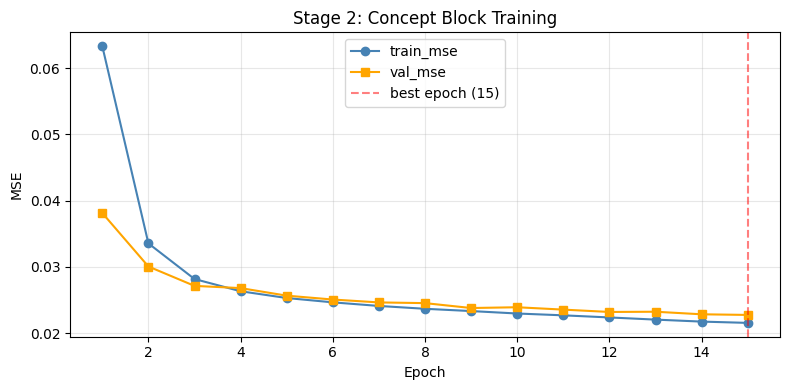


DIAGNOSTIC 2: Per-Concept MSE on Val Set

concept                  |      MSE |      MAE |  true_mean |  pred_mean
---------------------------------------------------------------------------
  degradation_severity   |  0.00610 |  0.05197 |     0.1910 |     0.2003
  pace_decay_rate        |  0.00882 |  0.06456 |     0.1516 |     0.1830
  strategic_window       |  0.04003 |  0.10437 |     0.1287 |     0.1094
  track_position_risk    |  0.04531 |  0.16104 |     0.3783 |     0.4106
  undercut_pressure      |  0.03230 |  0.07996 |     0.1890 |     0.1756
  endgame_proximity      |  0.00382 |  0.01297 |     0.0143 |     0.0153

DIAGNOSTIC 3: Pearson Correlation with Ground Truth

concept                  |  correlation | interpretation                
--------------------------------------------------------------------------------
  degradation_severity   |       0.9599 | excellent                     
  pace_decay_rate        |       0.9354 | excellent                     
  strategic_wind

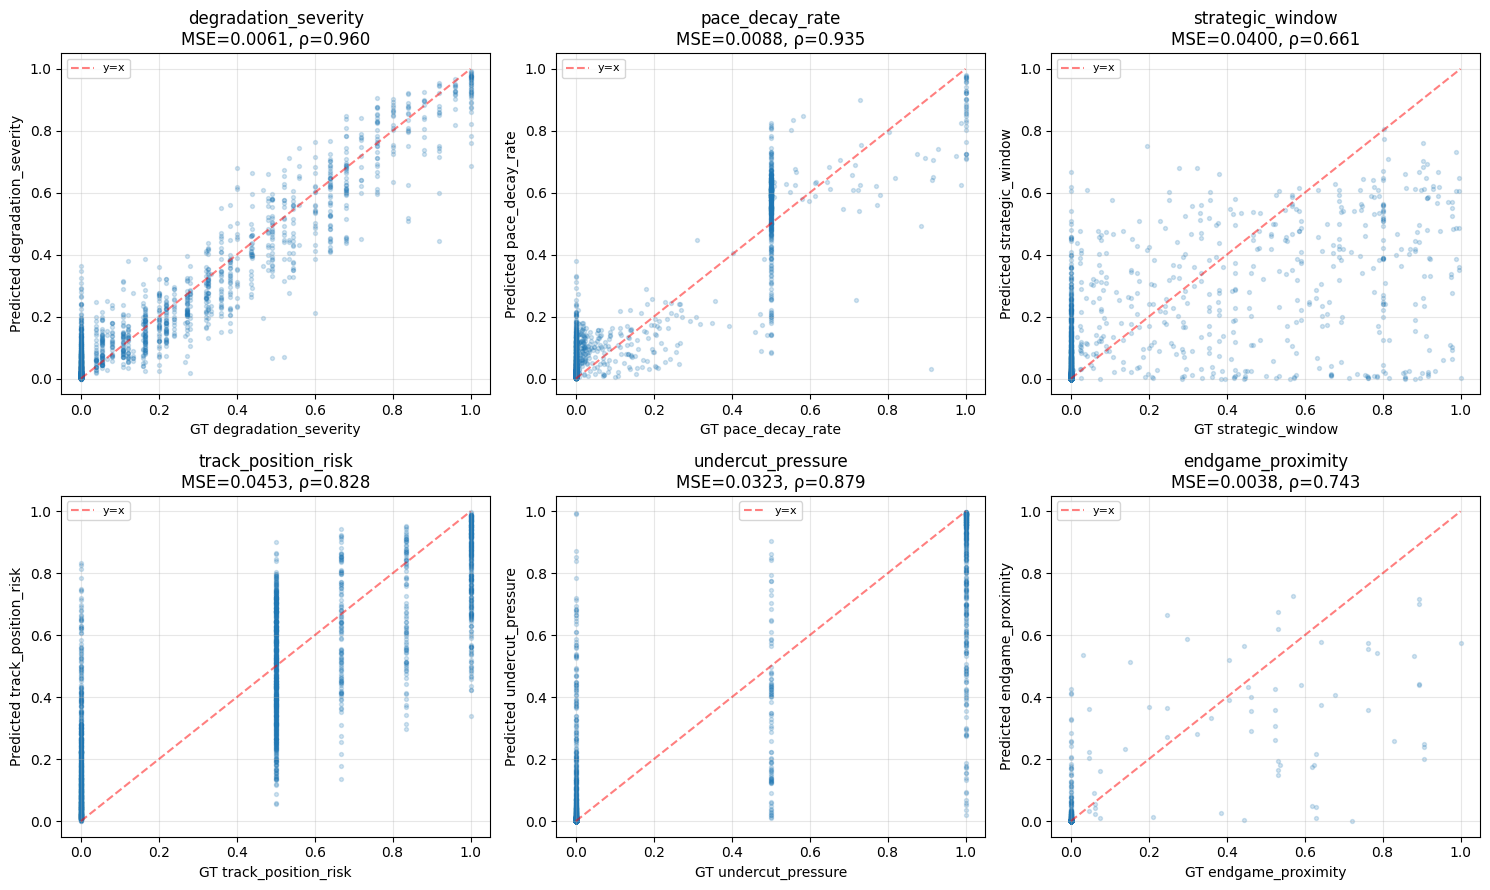


STAGE 2 DIAGNOSTIC SUMMARY
  Best val MSE:               0.02273
  Best epoch:                 15
  Per-concept correlation range: 0.661 to 0.960


In [4]:
# Section 4 — Stage 2 Diagnostics

print("=" * 70)
print("STAGE 2 DIAGNOSTICS")
print("=" * 70)

# Load best checkpoint
ckpt2 = torch.load(CHECKPOINTS_DIR / 'stage2_concept_block.pt', weights_only=False)
concept_block.load_state_dict(ckpt2['concept_block_state_dict'])
concept_block.eval()

# Generate predictions on val set
c_pred_list = []
c_true_list = []
with torch.no_grad():
    for zb, cb in val_loader:
        zb = zb.to(DEVICE); cb = cb.to(DEVICE)
        c_pred_list.append(concept_block(zb).cpu().numpy())
        c_true_list.append(cb.cpu().numpy())
c_pred = np.concatenate(c_pred_list, axis=0)
c_true = np.concatenate(c_true_list, axis=0)
pit_val = pit_train_arr[val_mask]
print(f"Generated predictions for {len(c_pred):,} val samples")


# ── Diagnostic 1: Training curves
print("\n" + "=" * 70)
print("DIAGNOSTIC 1: Training Curves")
print("=" * 70)

history = ckpt2['history']
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history['epoch'], history['train_loss'], 'o-', label='train_mse', color='steelblue')
ax.plot(history['epoch'], history['val_loss'], 's-', label='val_mse', color='orange')
ax.axvline(ckpt2['best_epoch'], color='red', linestyle='--', alpha=0.5, label=f"best epoch ({ckpt2['best_epoch']})")
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.set_title('Stage 2: Concept Block Training')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ── Diagnostic 2: Per-concept MSE
print("\n" + "=" * 70)
print("DIAGNOSTIC 2: Per-Concept MSE on Val Set")
print("=" * 70)

print(f"\n{'concept':<24s} | {'MSE':>8s} | {'MAE':>8s} | {'true_mean':>10s} | {'pred_mean':>10s}")
print("-" * 75)
for j, name in enumerate(CONCEPT_NAMES):
    mse = ((c_pred[:, j] - c_true[:, j]) ** 2).mean()
    mae = np.abs(c_pred[:, j] - c_true[:, j]).mean()
    print(f"  {name:<22s} | {mse:>8.5f} | {mae:>8.5f} | {c_true[:, j].mean():>10.4f} | {c_pred[:, j].mean():>10.4f}")


# ── Diagnostic 3: Pearson correlation with GT
print("\n" + "=" * 70)
print("DIAGNOSTIC 3: Pearson Correlation with Ground Truth")
print("=" * 70)

print(f"\n{'concept':<24s} | {'correlation':>12s} | {'interpretation':<30s}")
print("-" * 80)
for j, name in enumerate(CONCEPT_NAMES):
    if c_true[:, j].std() < 1e-6 or c_pred[:, j].std() < 1e-6:
        corr = np.nan
        interp = "constant target/prediction"
    else:
        corr = np.corrcoef(c_pred[:, j], c_true[:, j])[0, 1]
        if corr > 0.85:
            interp = "excellent"
        elif corr > 0.7:
            interp = "good"
        elif corr > 0.5:
            interp = "moderate"
        elif corr > 0.3:
            interp = "weak"
        else:
            interp = "poor"
    print(f"  {name:<22s} | {corr:>12.4f} | {interp:<30s}")


# ── Diagnostic 4: Class separation
print("\n" + "=" * 70)
print("DIAGNOSTIC 4: Class Separation (predicted concepts, val set)")
print("=" * 70)

print(f"\n{'concept':<24s} | {'pred|pit=0':>11s} | {'pred|pit=1':>11s} | {'gt|pit=0':>10s} | {'gt|pit=1':>10s}")
print("-" * 90)
for j, name in enumerate(CONCEPT_NAMES):
    pred_no_pit = c_pred[pit_val == 0, j].mean()
    pred_pit = c_pred[pit_val == 1, j].mean()
    gt_no_pit = c_true[pit_val == 0, j].mean()
    gt_pit = c_true[pit_val == 1, j].mean()
    print(f"  {name:<22s} | {pred_no_pit:>11.4f} | {pred_pit:>11.4f} | {gt_no_pit:>10.4f} | {gt_pit:>10.4f}")


# ── Diagnostic 5: Scatter plots (predicted vs ground truth)
print("\n" + "=" * 70)
print("DIAGNOSTIC 5: Predicted vs Ground Truth Scatter")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
sample_idx = np.random.RandomState(SEED).choice(len(c_pred), size=2000, replace=False)
for j, name in enumerate(CONCEPT_NAMES):
    ax = axes[j]
    ax.scatter(c_true[sample_idx, j], c_pred[sample_idx, j], alpha=0.2, s=8)
    ax.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='y=x')
    mse_j = ((c_pred[:, j] - c_true[:, j]) ** 2).mean()
    corr_j = np.corrcoef(c_pred[:, j], c_true[:, j])[0, 1] if c_true[:, j].std() > 1e-6 else np.nan
    ax.set_xlabel(f'GT {name}'); ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name}\nMSE={mse_j:.4f}, ρ={corr_j:.3f}')
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Summary
print("\n" + "=" * 70)
print("STAGE 2 DIAGNOSTIC SUMMARY")
print("=" * 70)
print(f"  Best val MSE:               {ckpt2['best_val_mse']:.5f}")
print(f"  Best epoch:                 {ckpt2['best_epoch']}")
print(f"  Per-concept correlation range: " +
      f"{min(np.corrcoef(c_pred[:,j], c_true[:,j])[0,1] for j in range(6) if c_true[:,j].std() > 1e-6):.3f} "
      f"to {max(np.corrcoef(c_pred[:,j], c_true[:,j])[0,1] for j in range(6) if c_true[:,j].std() > 1e-6):.3f}")